In [9]:
import copy
from collections.abc import Mapping
from copy import deepcopy
from typing import Any

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import matplotlib.pyplot as plt
import numpy as np
import optax
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from darnax.datasets.classification.cifar10 import Cifar10
from darnax.layer_maps.sparse import LayerMap
from darnax.modules.fully_connected import (
    FrozenRescaledFullyConnected,
    FullyConnected,
    SparseFullyConnected,
)
from darnax.modules.input_output import OutputLayer
from darnax.modules.recurrent import SparseRecurrentDiscrete
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.states.sequential import SequentialState
from darnax.trainers.dynamical import DynamicalTrainer
from darnax.utils.typing import PyTree
import json

In [3]:
PARAMS: dict[str, Any] = {
    "master_seed": 0,
    "epochs": 5,
    "model": {
        "kwargs": {
            "seed": 44,
            "dim_data": 3072,  # CIFAR10: 32x32x3 = 3072 (changed from 784 for MNIST)
            "dim_hidden": 2000,  # hidden size
            "num_labels": 10,  # number of classes
            "sparsity": 0.99,  # recurrent sparsity
            "sparsity_win": 0.9,  # input sparsity
            "strength_forth": 5.0,
            "strength_back": 1.3,
            "j_d": 0.95,  # self-coupling in recurrent J
            "threshold_in": 1.78,
            "threshold_out": 7.0,
            "threshold_j": 1.78,
            "threshold_back": 0.0,
        }
    },
    "data": {
        "kwargs": {
            "batch_size": 16,
            "linear_projection": None,
            "num_images_per_class": None,
            "label_mode": "pm1",
            "x_transform": "identity",
            # NOTE: Removed 'flatten' parameter - CIFAR10 handles flattening internally
        },
    },
    "optimizer": {
        "learning_rate_win": 0.159,  # input layer
        "learning_rate_j": 0.058,  # recurrent J
        "learning_rate_wout": 0.17,  # output layer
        "weight_decay_win": 0.01,
        "weight_decay_j": 0.00006,
        "weight_decay_wout": 0.02,
    },
    "trainer": {
        "kwargs": {
            "warmup_n_iter": 1,
            "train_clamped_n_iter": 5,
            "train_free_n_iter": 5,
            "eval_n_iter": 5,
        },
    },
    "torch_clf": {
        "enabled": True,
        "use_bias": False,
        "optimizer": "adam",
        "lr": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 256,
        "epochs": 20,
    },
}

In [4]:
def build_model(
    seed: int,
    dim_data: int,
    dim_hidden: int,
    sparsity: float,
    sparsity_win: float,
    num_labels: int,
    strength_forth: float,
    strength_back: float,
    threshold_in: float,
    threshold_out: float,
    threshold_back: float,
    threshold_j: float,
    j_d: float,
) -> tuple[SequentialState, SequentialOrchestrator]:
    """Build a sparse recurrent model with input, recurrent, output modules.

    The model has:

    - a sparse input adapter ``SparseFullyConnected``,
    - a sparse recurrent core ``SparseRecurrentDiscrete``,
    - a feedback adapter
    - an output adapter followed by ``OutputLayer``.

    Parameters
    ----------
    seed:
        PRNG seed for JAX initializations.
    dim_data:
        Input dimension.
    dim_hidden:
        Size of the recurrent layer.
    sparsity:
        Fraction of zero entries in the recurrent J matrix.
    sparsity_win:
        Fraction of zero entries in the input matrix W_in.
    num_labels:
        Number of output classes.
    strength_forth:
        Scaling factor for forward (input → hidden) couplings.
    strength_back:
        Scaling factor for feedback (output → hidden) couplings.
    threshold_in:
        Threshold for the input adapter dynamics.
    threshold_out:
        Threshold for the output adapter dynamics.
    threshold_back:
        Threshold for the feedback adapter dynamics.
    threshold_j:
        Threshold for the recurrent core.
    j_d:
        Diagonal self–coupling strength for the recurrent core.

    Returns
    -------
    state:
        Initial ``SequentialState`` with appropriate shapes.
    orchestrator:
        ``SequentialOrchestrator`` wiring all modules together.

    """
    state = SequentialState((dim_data, dim_hidden, num_labels))

    master_key = jax.random.key(seed)
    keys = jax.random.split(master_key, num=5)

    layer_map = {
        1: {
            0: SparseFullyConnected(
                in_features=dim_data,
                out_features=dim_hidden,
                strength=strength_forth,
                threshold=threshold_in,
                sparsity=sparsity_win,
                key=keys[0],
            ),
            1: SparseRecurrentDiscrete(
                features=dim_hidden,
                j_d=j_d,
                sparsity=sparsity,
                threshold=threshold_j,
                key=keys[1],
            ),
            2: FrozenRescaledFullyConnected(
                in_features=num_labels,
                out_features=dim_hidden,
                strength=strength_back,
                threshold=threshold_back,
                key=keys[2],
            ),
        },
        2: {
            1: FullyConnected(
                in_features=dim_hidden,
                out_features=num_labels,
                strength=1.0,
                threshold=threshold_out,
                key=keys[3],
            ),
            2: OutputLayer(),
        },
    }

    layer_map = LayerMap.from_dict(layer_map)
    orchestrator = SequentialOrchestrator(layers=layer_map)

    return state, orchestrator

In [5]:
def make_lr_map_v2(
    model: SequentialOrchestrator,
    overrides: Mapping[tuple[int, int], str] | None = None,
    default_label: str = "default",
) -> PyTree:
    """Build a PyTree of parameter labels for ``optax.multi_transform``.

    Parameters
    ----------
    model:
        Orchestrator model (must have a ``.lmap`` field).
    overrides:
        Optional mapping from ``(layer_idx, position_idx)`` to a label string.
        Example: ``{(1, 0): "w_in", (1, 1): "j", (2, 1): "w_out"}``.
    default_label:
        Label assigned to all parameters not specified in ``overrides``.

    Returns
    -------
    labels:
        PyTree matching the parameter structure, each leaf a string label.

    """
    params, _ = eqx.partition(model, eqx.is_inexact_array)

    def like(tree, value: str):
        """Broadcast a scalar label to a tree with the same structure."""
        return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

    labels = jtu.tree_map(lambda _: default_label, params, is_leaf=eqx.is_array)

    if overrides:
        for (i, j), label in overrides.items():
            labels = eqx.tree_at(
                lambda m: m.lmap[i][j],
                labels,
                replace=like(params.lmap[i][j], label),
            )

    return labels

In [6]:
def decay(
    orchestrator: SequentialOrchestrator,
    config: dict[str, Any],
) -> SequentialOrchestrator:
    """Apply exponential weight decay to input, recurrent, and output matrices.

    The decay factors are rescaled by the corresponding learning rates and by
    the layer dimensions, to match the effective SGD step size.

    Parameters
    ----------
    orchestrator:
        Current model orchestrator.
    config:
        Parameter dictionary (expects ``"optimizer"`` and
        ``"model"]["kwargs"]`` keys).

    Returns
    -------
    new_orch:
        New orchestrator with decayed weights.

    """
    new_orch = orchestrator

    dim_data = config["model"]["kwargs"]["dim_data"]
    dim_hidden = config["model"]["kwargs"]["dim_hidden"]

    # Input weights W_in
    W_in = jnp.asarray(new_orch.lmap[1][0].W)
    rescaling_win = (
        config["optimizer"]["weight_decay_win"]
        / (1 - config["model"]["kwargs"]["sparsity_win"]) ** 0.5
        * (
            (1 - 0.90) ** 0.5
        )  # the optimal hyperparamaters were found before this rescaling was introduced
        * config["optimizer"]["learning_rate_win"]
        / (dim_data**0.5)
    )
    W_in_new = W_in * (1.0 - rescaling_win)
    new_orch = eqx.tree_at(lambda o: o.lmap[1][0].W, new_orch, W_in_new)

    # Recurrent J (masked: we do not decay excluded entries)
    J = jnp.asarray(new_orch.lmap[1][1].J)
    mask = jnp.asarray(new_orch.lmap[1][1]._mask)
    rescaling_j = (
        config["optimizer"]["weight_decay_j"]
        * config["optimizer"]["learning_rate_j"]
        / (1 - config["model"]["kwargs"]["sparsity"]) ** 0.5
        * (
            (1 - 0.90) ** 0.5
        )  # the optimal hyperparamaters were found before this rescaling was introduced
        / (dim_hidden**0.5)
    )
    J_new = J * (1.0 - rescaling_j * mask)
    new_orch = eqx.tree_at(lambda o: o.lmap[1][1].J, new_orch, J_new)

    # Output weights W_out
    W_out = jnp.asarray(new_orch.lmap[2][1].W)
    rescaling_wout = (
        config["optimizer"]["weight_decay_wout"]
        * config["optimizer"]["learning_rate_wout"]
        / (dim_hidden**0.5)
    )
    W_out_new = W_out * (1.0 - rescaling_wout)
    new_orch = eqx.tree_at(lambda o: o.lmap[2][1].W, new_orch, W_out_new)

    return new_orch

In [7]:
def train_once(params: dict[str, Any]) -> tuple[dict[str, list[float]], Any, Any, jax.Array]:
    """Train the sparse recurrent model for a fixed number of epochs.

    Parameters
    ----------
    params:
        Experiment configuration dictionary (``PARAMS``).

    Returns
    -------
    history:
        Dictionary with lists of training and evaluation accuracies.
    trainer:
        Trained trainer object.
    ds:
        Dataset object used for training and evaluation.
    key:
        Final JAX PRNG key after training.

    """
    cfg = deepcopy(params)
    key = jax.random.key(cfg.get("master_seed", 0))

    # Build model and dataset
    state, orchestrator = build_model(**cfg["model"]["kwargs"])

    ds = Cifar10(**cfg["data"]["kwargs"])
    key, data_key = jax.random.split(key)
    ds.build(data_key)

    # Learning-rate map for optax.multi_transform
    lr_map = make_lr_map_v2(
        orchestrator,
        overrides={(1, 0): "w_in", (1, 1): "j", (2, 1): "w_out"},
    )

    lr_win = cfg["optimizer"]["learning_rate_win"]
    lr_wout = cfg["optimizer"]["learning_rate_wout"]
    lr_j = cfg["optimizer"]["learning_rate_j"]

    # Rescale learning rates to account for sparsity
    sparsity = cfg["model"]["kwargs"]["sparsity"]
    sparsity_win = cfg["model"]["kwargs"]["sparsity_win"]
    lr_j /= jnp.sqrt(1.0 - sparsity)
    lr_win /= jnp.sqrt(1.0 - sparsity_win)

    optimizer = optax.multi_transform(
        {
            "default": optax.sgd(learning_rate=0.0),
            "w_in": optax.sgd(learning_rate=lr_win),
            "w_out": optax.sgd(learning_rate=lr_wout),
            "j": optax.sgd(learning_rate=lr_j),
        },
        lr_map,
    )
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

    trainer = DynamicalTrainer(
        orchestrator=orchestrator,
        state=state,
        optimizer=optimizer,
        optimizer_state=opt_state,
        **cfg["trainer"]["kwargs"],
    )

    history: dict[str, list[float]] = {
        "train_acc": [],
        "eval_acc": [],
    }

    num_epochs = int(cfg["epochs"])

    for epoch in range(0, num_epochs + 1):
        # ---- Train ----
        if epoch != 0:
            for xb, yb in ds:
                key = trainer.train_step(xb, yb, key)
                trainer.orchestrator = decay(trainer.orchestrator, cfg)

        # ---- Eval on test split ----
        accs_eval = []
        for xb, yb in ds.iter_test():
            key, metrics = trainer.eval_step(xb, yb, key)
            accs_eval.append(metrics["accuracy"])

        acc_eval = float(jnp.mean(jnp.array(accs_eval))) if accs_eval else float("nan")

        # ---- Eval on train split ----
        accs_train = []
        for xb, yb in ds:
            key, metrics = trainer.eval_step(xb, yb, key)
            accs_train.append(metrics["accuracy"])
        acc_train = float(jnp.mean(jnp.array(accs_train))) if accs_train else float("nan")

        history["train_acc"].append(acc_train)
        history["eval_acc"].append(acc_eval)

        print(f"Epoch {epoch:03d} | train_acc={acc_train:.4f} | eval_acc={acc_eval:.4f}")

    return history, trainer, ds, key

In [8]:
def train_torch_linear_probe(
    trainer: Any,
    ds: Any,
    cfg: dict[str, Any],
    key: jax.Array,
) -> None:
    """Train a linear classifier on frozen JAX representations using PyTorch.

    Parameters
    ----------
    trainer:
        Trained darnax trainer (provides ``.state.representations``).
    ds:
        Dataset object with train and test iterators.
    cfg:
        Experiment config with ``"model"`` and ``"torch_clf"`` sections.
    key:
        JAX PRNG key (updated during evaluation passes).

    """
    if "torch_clf" not in cfg or not cfg["torch_clf"].get("enabled", False):
        print("Torch linear probe is disabled in PARAMS['torch_clf'].")
        return

    torch_clf_cfg = cfg["torch_clf"]
    print("Starting PyTorch linear classifier training...")

    if "master_seed" in cfg:
        torch.manual_seed(int(cfg["master_seed"]))

    # Feature extraction: train split
    train_reps = []
    train_labels = []
    for xb, yb in ds:
        key, _ = trainer.eval_step(xb, yb, key)
        reps = trainer.state[-2]
        train_reps.append(copy.deepcopy(np.array(reps)))
        yb_np = np.array(copy.deepcopy(yb))
        yb_np = np.argmax(yb_np, axis=-1)
        train_labels.append(copy.deepcopy(yb_np))

    # Feature extraction: test split
    test_reps = []
    test_labels = []
    for xb, yb in ds.iter_test():
        key, _ = trainer.eval_step(xb, yb, key)
        reps = trainer.state[-2]
        test_reps.append(copy.deepcopy(np.array(reps)))
        yb_np = np.array(copy.deepcopy(yb))
        yb_np = np.argmax(yb_np, axis=-1)
        test_labels.append(copy.deepcopy(yb_np))

    features_train = torch.from_numpy(np.concatenate(train_reps, axis=0)).float()
    labels_train = torch.from_numpy(np.concatenate(train_labels, axis=0)).long()
    features_test = torch.from_numpy(np.concatenate(test_reps, axis=0)).float()
    labels_test = torch.from_numpy(np.concatenate(test_labels, axis=0)).long()

    input_dim = int(features_train.shape[1])
    num_classes = int(cfg["model"]["kwargs"]["num_labels"])

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = nn.Linear(input_dim, num_classes, bias=torch_clf_cfg.get("use_bias", False)).to(device)
    criterion = nn.CrossEntropyLoss()
    opt_name = torch_clf_cfg.get("optimizer", "adam").lower()
    opt_class = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[opt_name]
    optimizer = opt_class(
        model.parameters(),
        lr=float(torch_clf_cfg["lr"]),
        weight_decay=float(torch_clf_cfg["weight_decay"]),
    )

    batch_size = int(torch_clf_cfg["batch_size"])
    train_loader = DataLoader(
        TensorDataset(features_train, labels_train),
        batch_size=batch_size,
        shuffle=True,
    )

    epochs_clf = int(torch_clf_cfg["epochs"])

    for e in range(epochs_clf):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for xb_t, yb_t in train_loader:
            xb_t = xb_t.to(device)
            yb_t = yb_t.to(device)
            optimizer.zero_grad()
            logits = model(xb_t)
            loss = criterion(logits, yb_t)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * yb_t.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb_t).sum().item()
            total += yb_t.size(0)

        train_loss = total_loss / max(1, total)
        train_acc = correct / max(1, total)

        model.eval()
        with torch.no_grad():
            logits_eval = model(features_test.to(device))
            eval_loss = criterion(logits_eval, labels_test.to(device)).item()
            pred_eval = logits_eval.argmax(dim=1)
            eval_acc = (pred_eval == labels_test.to(device)).float().mean().item()

        print(
            f"[Torch Clf] Epoch {e:03d} | "
            f"train_acc={train_acc:.4f} | eval_acc={eval_acc:.4f} | "
            f"train_loss={train_loss:.4f} | eval_loss={eval_loss:.4f}"
        )

    print("PyTorch linear classifier training complete.")

Epoch 000 | train_acc=0.0999 | eval_acc=0.0961
Epoch 001 | train_acc=0.2302 | eval_acc=0.2291
Epoch 002 | train_acc=0.1883 | eval_acc=0.1832
Epoch 003 | train_acc=0.2639 | eval_acc=0.2549
Epoch 004 | train_acc=0.2638 | eval_acc=0.2514


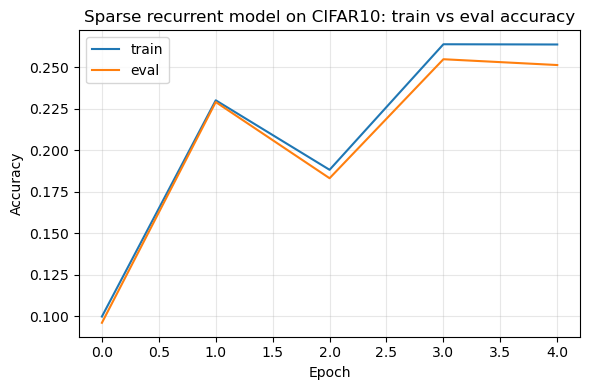

In [15]:
history, trainer, ds, key = train_once(PARAMS)

plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["eval_acc"], label="eval")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Sparse recurrent model on CIFAR10: train vs eval accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
if PARAMS["torch_clf"]["enabled"]:
    train_torch_linear_probe(trainer, ds, PARAMS, key)

Starting PyTorch linear classifier training...
[Torch Clf] Epoch 000 | train_acc=0.2357 | eval_acc=0.2943 | train_loss=2.0970 | eval_loss=1.9632
[Torch Clf] Epoch 001 | train_acc=0.2946 | eval_acc=0.2989 | train_loss=1.9662 | eval_loss=1.9390
[Torch Clf] Epoch 002 | train_acc=0.3136 | eval_acc=0.3195 | train_loss=1.9216 | eval_loss=1.9123
[Torch Clf] Epoch 003 | train_acc=0.3178 | eval_acc=0.2993 | train_loss=1.9086 | eval_loss=1.9160
[Torch Clf] Epoch 004 | train_acc=0.3233 | eval_acc=0.2958 | train_loss=1.8936 | eval_loss=1.9501
[Torch Clf] Epoch 005 | train_acc=0.3269 | eval_acc=0.3010 | train_loss=1.8868 | eval_loss=1.9158
[Torch Clf] Epoch 006 | train_acc=0.3331 | eval_acc=0.3152 | train_loss=1.8713 | eval_loss=1.9095
[Torch Clf] Epoch 007 | train_acc=0.3350 | eval_acc=0.3067 | train_loss=1.8663 | eval_loss=1.9476
[Torch Clf] Epoch 008 | train_acc=0.3349 | eval_acc=0.3393 | train_loss=1.8732 | eval_loss=1.8635
[Torch Clf] Epoch 009 | train_acc=0.3355 | eval_acc=0.3129 | train_loss

## Hyper-parameter experiments

### J_d

In [ ]:
base = deepcopy(PARAMS)

J_ds = [0.5, 0.8, 0.95, 0.99]

histories = {}

for j_d in J_ds:
    base["model"]["kwargs"]["j_d"] = j_d

    history, trainer, ds, key = train_once(base)
    histories[j_d] = history
    
with open("results/hyperparam_tests/cifar10_jd_histories.json", "w") as f:
    json.dump(histories, f)

/opt/anaconda3/envs/brainAI/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=bool with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 000 | train_acc=0.0999 | eval_acc=0.0961
Epoch 001 | train_acc=0.2302 | eval_acc=0.2291
Epoch 002 | train_acc=0.1883 | eval_acc=0.1832
Epoch 003 | train_acc=0.2639 | eval_acc=0.2549
Epoch 004 | train_acc=0.2638 | eval_acc=0.2514


### Hidden size

In [ ]:
base = deepcopy(PARAMS)

dim_hiddens = [500, 1000, 2000, 4000]
histories = {}

for dim_hidden in dim_hiddens:
    base["model"]["kwargs"]["dim_hidden"] = dim_hidden

    history, trainer, ds, key = train_once(base)
    histories[dim_hidden] = history

with open("results/hyperparam_tests/cifar10_dim_hidden_histories.json", "w") as f:
    json.dump(histories, f)

### Learning rate J

In [ ]:
base = deepcopy(PARAMS)

learning_rates = [0.01, 0.04, 0.058, 0.1]
histories = {}

for lr in learning_rates:
    base["optimizer"]["learning_rate_j"] = lr
    history, trainer, ds, key = train_once(base)
    histories[lr] = history

with open("results/hyperparam_tests/cifar10_lr_j_histories.json", "w") as f:
    json.dump(histories, f)

### Sparsity

In [ ]:
base = deepcopy(PARAMS)

sparsities = [0.9, 0.95, 0.99, 0.995]
histories = {}

for sparsity in sparsities:
    base["model"]["kwargs"]["sparsity"] = sparsity
    history, trainer, ds, key = train_once(base)
    histories[sparsity] = history

with open("results/hyperparam_tests/cifar10_sparsity_histories.json", "w") as f:
    json.dump(histories, f)